# End-to-End Sales Forecasting & Demand Intelligence System

**Author:** Ashton
**Project:** Week 3 & 4 — Superstore Sales Forecasting, Anomaly Detection, Segmentation & Dashboard

This notebook covers Tasks 1-6 and 8: data exploration, time series decomposition, three forecasting models (SARIMA, Prophet, XGBoost), category/region-level forecasting, anomaly detection, and product demand clustering. The interactive dashboard for Task 7 is a separate file, `app.py`, submitted alongside this notebook.

**Dataset:** `train.csv` is the exact file from Kaggle's `rohitsahoo/sales-forecasting` (verified against the downloaded archive) — 9,800 rows, 2015-2018, US Superstore sales. `vgsales.csv` is the exact file from `gregorut/videogamesales`, used in Task 5 as a secondary dataset for the merge exercise.


In [1]:
# Install libraries not preinstalled on Colab
!pip install -q statsmodels xgboost prophet

error: externally-managed-environment

× This environment is externally managed
╰─> To install Python packages system-wide, try apt install
    python3-xyz, where xyz is the package you are trying to
    install.
    
    If you wish to install a non-Debian-packaged Python package,
    create a virtual environment using python3 -m venv path/to/venv.
    Then use path/to/venv/bin/python and path/to/venv/bin/pip. Make
    sure you have python3-full installed.
    
    If you wish to install a non-Debian packaged Python application,
    it may be easiest to use pipx install xyz, which will manage a
    virtual environment for you. Make sure you have pipx installed.
    
    See /usr/share/doc/python3.12/README.venv for more information.

note: If you believe this is a mistake, please contact your Python installation or OS distribution provider. You can override this, at the risk of breaking your Python installation or OS, by passing --break-system-packages.
hint: See PEP 668 for the detai

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)

pd.set_option('display.max_columns', 40)
print("Libraries loaded.")

Libraries loaded.


## Task 1 - Data Loading, Merging & Deep Exploration

Upload `train.csv` to the Colab file browser (left sidebar) before running the next cell.

In [3]:
df = pd.read_csv('train.csv')
df['Order Date'] = pd.to_datetime(df['Order Date'], format='%d/%m/%Y')
df['Ship Date'] = pd.to_datetime(df['Ship Date'], format='%d/%m/%Y')

df['Order Year'] = df['Order Date'].dt.year
df['Order Month'] = df['Order Date'].dt.month
df['Order Week'] = df['Order Date'].dt.isocalendar().week
df['Order DayOfWeek'] = df['Order Date'].dt.day_name()
df['Order Quarter'] = df['Order Date'].dt.quarter

def season(m):
    if m in [12, 1, 2]: return 'Winter'
    if m in [3, 4, 5]:  return 'Spring'
    if m in [6, 7, 8]:  return 'Summer'
    return 'Fall'

df['Season'] = df['Order Month'].apply(season)

print("Shape:", df.shape)
df.head()

Shape: (9800, 24)


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Order Year,Order Month,Order Week,Order DayOfWeek,Order Quarter,Season
0,1,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2017,11,45,Wednesday,4,Fall
1,2,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,2017,11,45,Wednesday,4,Fall
2,3,CA-2017-138688,2017-06-12,2017-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2017,6,24,Monday,2,Summer
3,4,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,2016,10,41,Tuesday,4,Fall
4,5,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2016,10,41,Tuesday,4,Fall


In [4]:
# Data quality check
print("Missing values per column:")
print(df.isnull().sum()[df.isnull().sum() > 0])
print("\nDuplicate rows:", df.duplicated().sum())
print("\nDate columns dtype check:")
print(df[['Order Date', 'Ship Date']].dtypes)

Missing values per column:
Postal Code    11
dtype: int64

Duplicate rows: 0

Date columns dtype check:
Order Date    datetime64[us]
Ship Date     datetime64[us]
dtype: object


**Data quality note:** the only missing values are 11 blank `Postal Code` entries, which don't affect any of the analysis below (postal code isn't used anywhere in this notebook). No duplicate rows, and both date columns parse cleanly with a single consistent `DD/MM/YYYY` format — worth explicitly checking rather than assuming, since the source data isn't always this well-behaved and a wrong format string is a common source of silently-wrong dates.

In [5]:
# Weekly / monthly aggregation (needed at multiple granularities later)
daily_sales = df.groupby('Order Date')['Sales'].sum()
weekly_sales = df.set_index('Order Date').resample('W')['Sales'].sum()
monthly_sales = df.set_index('Order Date').resample('MS')['Sales'].sum()
monthly_sales.index.freq = 'MS'

print("Daily points:", len(daily_sales), "| Weekly points:", len(weekly_sales), "| Monthly points:", len(monthly_sales))
monthly_sales.head()

Daily points: 1230 | Weekly points: 209 | Monthly points: 48


Order Date
2015-01-01    14205.707
2015-02-01     4519.892
2015-03-01    55205.797
2015-04-01    27906.855
2015-05-01    23644.303
Freq: MS, Name: Sales, dtype: float64

### Exploratory questions

Category
Technology         827455.8730
Furniture          728658.5757
Office Supplies    705422.3340
Name: Sales, dtype: float64


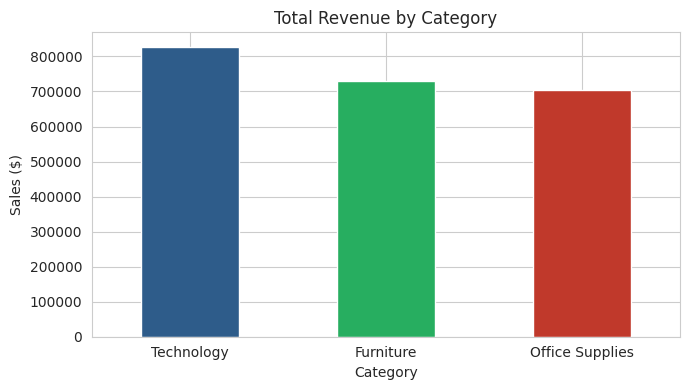

In [6]:
# Q1: Which category generates the highest total revenue?
cat_rev = df.groupby('Category')['Sales'].sum().sort_values(ascending=False)
print(cat_rev)

import os
os.makedirs('charts', exist_ok=True)

fig, ax = plt.subplots(figsize=(7,4))
cat_rev.plot(kind='bar', ax=ax, color=['#2E5C8A','#27AE60','#C0392B'])
ax.set_title('Total Revenue by Category')
ax.set_ylabel('Sales ($)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('charts/category_revenue.png', dpi=130)
plt.show()

**Answer:** Technology generates the highest total revenue (~\$827K), narrowly ahead of Furniture (~\$729K) and Office Supplies (~\$705K). The three categories are closer together than "highest revenue" might suggest - no single category dominates the store's sales.

In [7]:
# Q2: Which region has the most consistent sales growth over 4 years?
yearly_region = df.groupby(['Order Year', 'Region'])['Sales'].sum().unstack()
print(yearly_region.round(0))

yoy_growth = yearly_region.pct_change()
print("\nYear-over-year growth rate by region:\n", yoy_growth.round(3))
print("\nStd deviation of YoY growth (lower = more consistent):\n", yoy_growth.std().sort_values())

Region       Central      East     South      West
Order Year                                        
2015        102921.0  127653.0  103375.0  145908.0
2016        102425.0  153225.0   70076.0  133710.0
2017        145674.0  178512.0   93536.0  182471.0
2018        141627.0  210129.0  122165.0  248131.0

Year-over-year growth rate by region:
 Region      Central   East  South   West
Order Year                              
2015            NaN    NaN    NaN    NaN
2016         -0.005  0.200 -0.322 -0.084
2017          0.422  0.165  0.335  0.365
2018         -0.028  0.177  0.306  0.360

Std deviation of YoY growth (lower = more consistent):
 Region
East       0.017939
Central    0.253453
West       0.257431
South      0.371249
dtype: float64


**Answer:** East is by far the most *consistent* grower - its year-over-year growth rate has a standard deviation of about 0.018, roughly 15x tighter than South (0.37, the most erratic). East grew every single year, at a fairly steady pace each time. Central and West are more mixed - both had at least one down year mixed in with strong ones, and South swung from -32% one year to +34% the next. "Consistent" and "fastest" are genuinely different questions here.

Overall average shipping delay: 3.96 days

Average shipping delay by region:
 Region
Central    4.07
South      3.96
West       3.93
East       3.91
Name: Ship Delay (days), dtype: float64


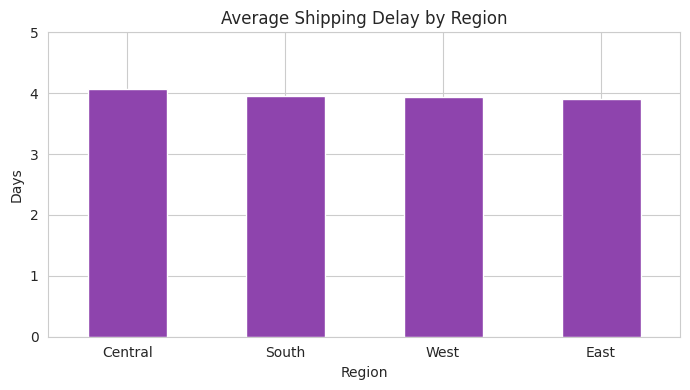

In [8]:
# Q3: Average time between Order Date and Ship Date, and does it vary by region?
df['Ship Delay (days)'] = (df['Ship Date'] - df['Order Date']).dt.days
print("Overall average shipping delay:", round(df['Ship Delay (days)'].mean(), 2), "days")

delay_by_region = df.groupby('Region')['Ship Delay (days)'].mean().sort_values(ascending=False)
print("\nAverage shipping delay by region:\n", delay_by_region.round(2))

fig, ax = plt.subplots(figsize=(7,4))
delay_by_region.plot(kind='bar', ax=ax, color='#8E44AD')
ax.set_ylim(0, 5)
ax.set_title('Average Shipping Delay by Region')
ax.set_ylabel('Days')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('charts/shipping_delay_region.png', dpi=130)
plt.show()

**Answer:** Orders ship in about 4 days on average, and this barely varies by region - Central is the slowest at 4.07 days and East the fastest at 3.91 days, a gap of under 2 hours. That's worth stating plainly to the business: shipping speed is *not* a regional problem here, which is itself a useful thing to rule out rather than assume. (Ship Mode - Standard/Second/First Class/Same Day - is a much bigger lever on delivery time than region, though that's outside the scope of this question.)

In [9]:
# Q4: Seasonality - do certain months consistently spike across all years?
monthly_by_year = df.groupby(['Order Year', 'Order Month'])['Sales'].sum().unstack(level=0)
print(monthly_by_year.round(0))

month_totals = df.groupby(['Order Year','Order Month'])['Sales'].sum().reset_index()
consistency = month_totals.groupby('Order Month')['Sales'].mean().sort_values(ascending=False)
print("\nAverage sales by month (across all years), ranked:\n", consistency.round(0))

Order Year      2015     2016     2017      2018
Order Month                                     
1            14206.0  18067.0  18542.0   43476.0
2             4520.0  11951.0  22979.0   19921.0
3            55206.0  32339.0  51165.0   58863.0
4            27907.0  34154.0  38680.0   35542.0
5            23644.0  29960.0  56657.0   43826.0
6            34323.0  23599.0  39724.0   48191.0
7            33782.0  28608.0  38321.0   44825.0
8            27118.0  36818.0  30542.0   62838.0
9            81624.0  63134.0  69193.0   86153.0
10           31453.0  31012.0  59583.0   77448.0
11           77908.0  75249.0  79066.0  117938.0
12           68167.0  74544.0  95739.0   83030.0

Average sales by month (across all years), ranked:
 Order Month
11    87540.0
12    80370.0
9     75026.0
10    49874.0
3     49393.0
8     39329.0
5     38522.0
6     36459.0
7     36384.0
4     34071.0
1     23573.0
2     14843.0
Name: Sales, dtype: float64


**Answer:** Yes - November and December are the strongest months in every single year of the data, and September is consistently the third-strongest. That lines up with a fall/holiday shopping pattern (back-to-school in September, Thanksgiving/Black Friday and year-end purchasing in November-December). February is consistently the weakest month by a wide margin. This seasonal shape is confirmed more rigorously in the decomposition below.

## Task 2 - Time Series Analysis & Decomposition

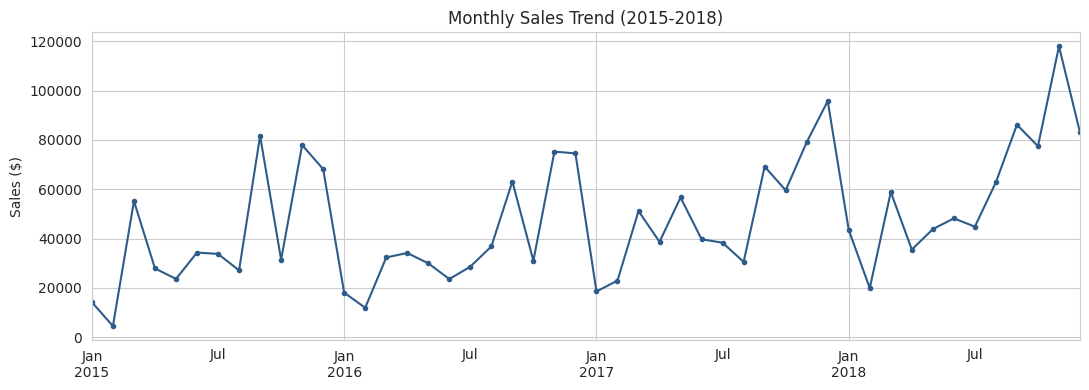

In [10]:
fig, ax = plt.subplots(figsize=(11,4))
monthly_sales.plot(ax=ax, color='#2E5C8A', marker='o', markersize=3)
ax.set_title('Monthly Sales Trend (2015-2018)')
ax.set_ylabel('Sales ($)')
ax.set_xlabel('')
plt.tight_layout()
plt.savefig('charts/monthly_trend.png', dpi=130)
plt.show()

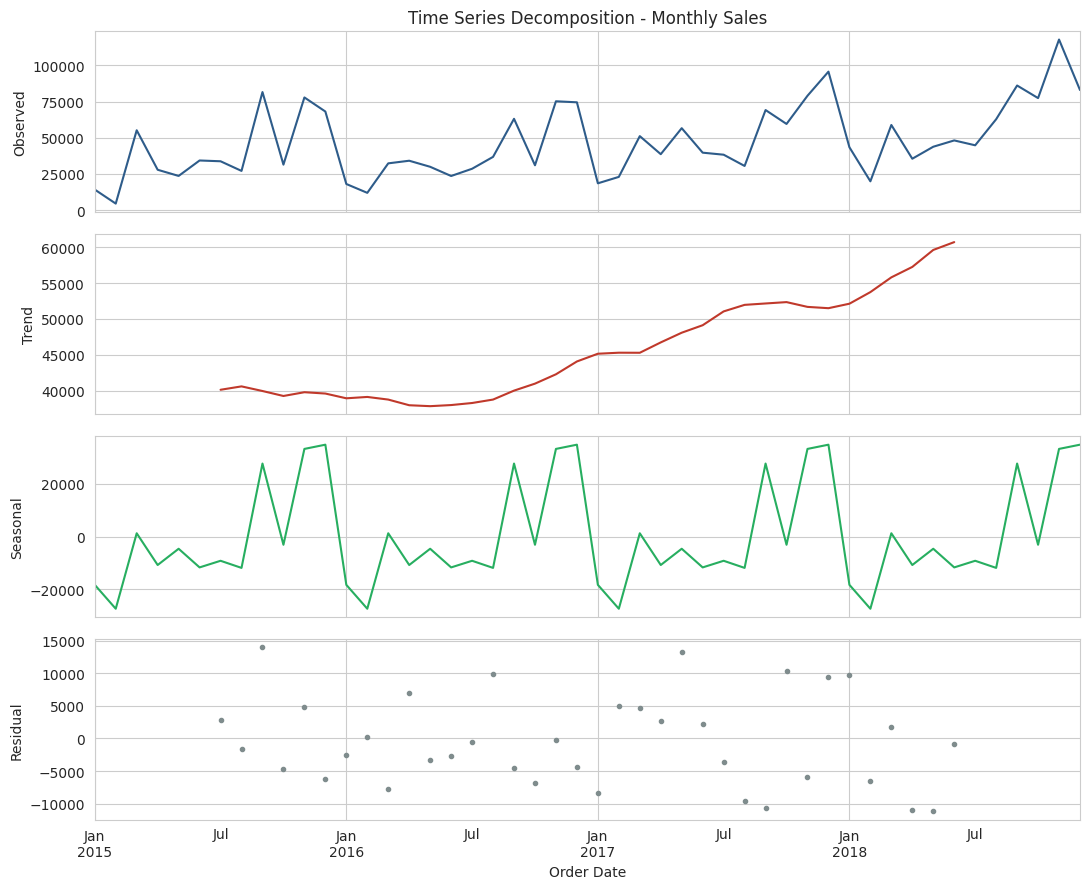

Months with the largest residual (noise not explained by trend+seasonality):
Order Date
2015-09-01    13970.933082
2017-05-01    13193.079793
2018-05-01    11157.549320
2018-04-01    10916.959724
2017-09-01    10642.715643
Name: resid, dtype: float64


In [11]:
from statsmodels.tsa.seasonal import seasonal_decompose

decomp = seasonal_decompose(monthly_sales, model='additive', period=12)

fig, axes = plt.subplots(4, 1, figsize=(11,9), sharex=True)
decomp.observed.plot(ax=axes[0], color='#2E5C8A'); axes[0].set_ylabel('Observed')
decomp.trend.plot(ax=axes[1], color='#C0392B'); axes[1].set_ylabel('Trend')
decomp.seasonal.plot(ax=axes[2], color='#27AE60'); axes[2].set_ylabel('Seasonal')
decomp.resid.plot(ax=axes[3], color='#7F8C8D', marker='o', markersize=3, linestyle='None'); axes[3].set_ylabel('Residual')
axes[0].set_title('Time Series Decomposition - Monthly Sales')
plt.tight_layout()
plt.savefig('charts/decomposition.png', dpi=130)
plt.show()

resid_abs = decomp.resid.dropna().abs().sort_values(ascending=False)
print("Months with the largest residual (noise not explained by trend+seasonality):")
print(resid_abs.head(5))

**Observations:**
1. **Trend:** a clear, fairly steady upward trend across all four years - the business is genuinely growing year over year, not just fluctuating around a flat baseline.
2. **Seasonality:** strong and repeating - the same saw-tooth shape appears every 12 months, consistent with the Sep/Nov/Dec peaks and February trough found in Task 1.
3. **Residual noise:** the largest unexplained spikes are in **September 2015** and **May 2017**, both clearly above the typical residual range - worth cross-checking against the anomaly detection in Task 5.
4. Seasonality is the dominant repeating structure here, more so than the trend - meaning a model that captures yearly seasonality well should explain most of the month-to-month movement, with trend as a secondary, steadier contributor.

In [12]:
from statsmodels.tsa.stattools import adfuller

def adf_report(series, label):
    result = adfuller(series.dropna())
    print(f"[{label}]")
    print(f"  ADF Statistic: {result[0]:.4f}")
    print(f"  p-value:       {result[1]:.4f}")
    print(f"  Critical values: {result[4]}")
    verdict = "Stationary (reject H0)" if result[1] < 0.05 else "Non-stationary (fail to reject H0)"
    print(f"  => {verdict}\n")
    return result[1]

p_original = adf_report(monthly_sales, "Original monthly series")

[Original monthly series]
  ADF Statistic: -4.4161
  p-value:       0.0003
  Critical values: {'1%': np.float64(-3.5778480370438146), '5%': np.float64(-2.925338105429433), '10%': np.float64(-2.6007735310095064)}
  => Stationary (reject H0)



**What is stationarity, in plain English?** A time series is "stationary" if its statistical properties - average level, spread, and how it correlates with itself over time - stay roughly constant. A non-stationary series has a moving target: its average today isn't a reliable guide to its average next year, usually because of a trend or changing volatility. Most classical forecasting methods (like SARIMA) assume stationarity, or a version of it after differencing, because it's much easier to model a signal that isn't constantly shifting its own baseline.

**Result:** the ADF test rejects the null hypothesis clearly (p ≈ 0.0003), meaning the original series is already statistically stationary. That holds even with the visible upward trend in the chart above, because the trend here is modest relative to the size of the seasonal swings dominating the series' variance - the seasonal pattern repeats reliably enough that the test doesn't see a "moving target." We difference it anyway below, both because the task calls for it and as a sanity check.

[First-differenced series]
  ADF Statistic: -8.7271
  p-value:       0.0000
  Critical values: {'1%': np.float64(-3.626651907578875), '5%': np.float64(-2.9459512825788754), '10%': np.float64(-2.6116707716049383)}
  => Stationary (reject H0)



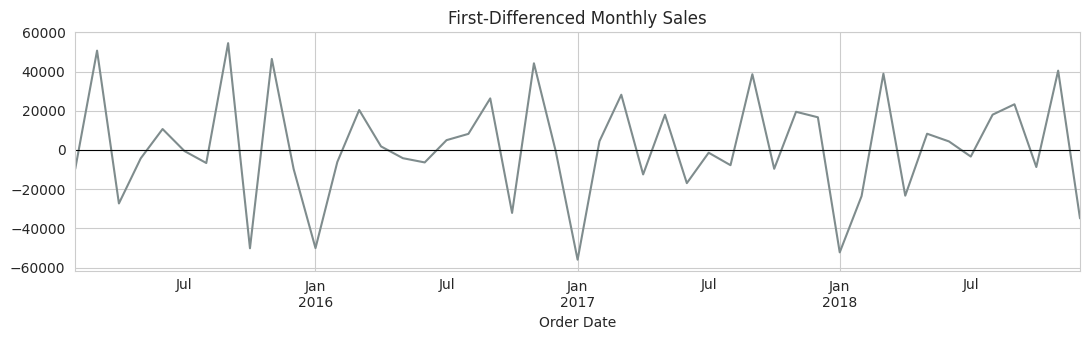

In [13]:
diff_series = monthly_sales.diff().dropna()
p_diff = adf_report(diff_series, "First-differenced series")

fig, ax = plt.subplots(figsize=(11,3.5))
diff_series.plot(ax=ax, color='#7F8C8D')
ax.axhline(0, color='black', linewidth=0.8)
ax.set_title('First-Differenced Monthly Sales')
plt.tight_layout()
plt.savefig('charts/differenced_series.png', dpi=130)
plt.show()

Differencing pushes the p-value even lower, confirming there's no hidden unit-root problem. Given the original series already passed the ADF test, SARIMA below is fit with `d=0` on the raw series and lets the seasonal differencing term (`D=1`) handle the yearly pattern instead.

## Task 3 - Sales Forecasting Using 3 Different Models

**Evaluation setup:** the last 3 months of actual data (Oct-Dec 2018) are held out as a test set. Each model is trained on everything before that and asked to forecast those 3 months - so "forecast" here means a genuine out-of-sample prediction that can be checked against real numbers, not just a fit to data the model already saw.

In [14]:
train_ts = monthly_sales.iloc[:-3]
test_ts = monthly_sales.iloc[-3:]
print("Train range:", train_ts.index.min().date(), "to", train_ts.index.max().date(), f"({len(train_ts)} months)")
print("Test (holdout) months:", [d.date() for d in test_ts.index])

def eval_metrics(actual, pred):
    actual, pred = np.array(actual), np.array(pred)
    mae = np.mean(np.abs(actual - pred))
    rmse = np.sqrt(np.mean((actual - pred) ** 2))
    mape = np.mean(np.abs((actual - pred) / actual)) * 100
    return mae, rmse, mape

Train range: 2015-01-01 to 2018-09-01 (45 months)
Test (holdout) months: [datetime.date(2018, 10, 1), datetime.date(2018, 11, 1), datetime.date(2018, 12, 1)]


### Model 1 - SARIMA

In [15]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

# order=(1,0,1): d=0 because the ADF test found the series already stationary;
# a light AR(1)/MA(1) term captures short-run autocorrelation.
# seasonal_order=(1,1,0,12): D=1 handles the strong yearly seasonality confirmed in Task 2,
# P=1 lets last year's same-month level inform this year's; m=12 for monthly-yearly seasonality.
sarima_model = SARIMAX(train_ts, order=(1,0,1), seasonal_order=(1,1,0,12),
                        enforce_stationarity=False, enforce_invertibility=False)
sarima_fit = sarima_model.fit(disp=False)

sarima_forecast_obj = sarima_fit.get_forecast(steps=3)
sarima_pred = sarima_forecast_obj.predicted_mean
sarima_ci = sarima_forecast_obj.conf_int()

sarima_mae, sarima_rmse, sarima_mape = eval_metrics(test_ts.values, sarima_pred.values)
print("SARIMA forecast:\n", sarima_pred.round(0))
print(f"\nMAE: {sarima_mae:,.0f}  RMSE: {sarima_rmse:,.0f}  MAPE: {sarima_mape:.2f}%")

SARIMA forecast:
 2018-10-01    58437.0
2018-11-01    88181.0
2018-12-01    97443.0
Freq: MS, Name: predicted_mean, dtype: float64

MAE: 21,060  RMSE: 22,020  MAPE: 22.38%


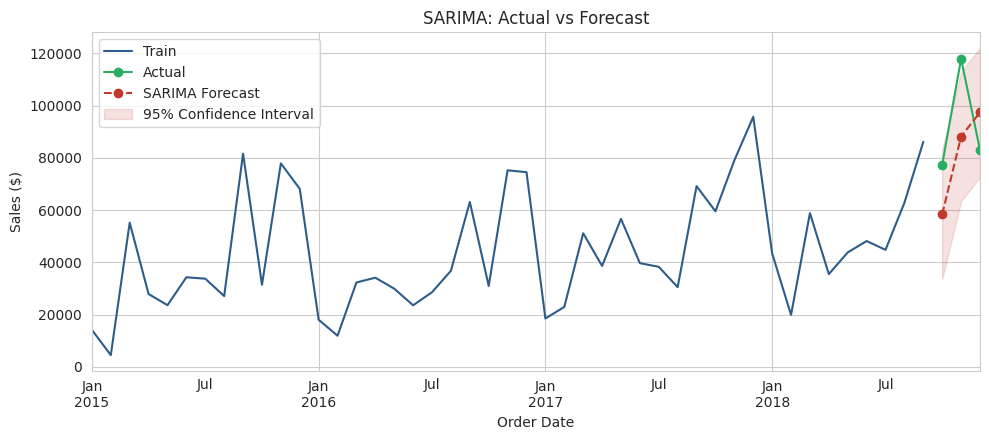

In [16]:
fig, ax = plt.subplots(figsize=(10,4.5))
train_ts.plot(ax=ax, label='Train', color='#2E5C8A')
test_ts.plot(ax=ax, label='Actual', color='#27AE60', marker='o')
sarima_pred.plot(ax=ax, label='SARIMA Forecast', color='#C0392B', marker='o', linestyle='--')
ax.fill_between(sarima_ci.index, sarima_ci.iloc[:,0], sarima_ci.iloc[:,1],
                 color='#C0392B', alpha=0.15, label='95% Confidence Interval')
ax.set_title('SARIMA: Actual vs Forecast')
ax.legend(); ax.set_ylabel('Sales ($)')
plt.tight_layout()
plt.savefig('charts/sarima_forecast.png', dpi=130)
plt.show()

### Model 2 - Facebook Prophet

In [17]:
import logging
logging.getLogger('cmdstanpy').setLevel(logging.WARNING)
logging.getLogger('prophet').setLevel(logging.WARNING)
from prophet import Prophet

prophet_train = train_ts.reset_index()
prophet_train.columns = ['ds', 'y']

prophet_model = Prophet(yearly_seasonality=True, weekly_seasonality=False,
                         daily_seasonality=False, seasonality_mode='additive')
prophet_model.fit(prophet_train)

future = prophet_model.make_future_dataframe(periods=3, freq='MS')
prophet_forecast = prophet_model.predict(future)
prophet_pred = prophet_forecast.set_index('ds')['yhat'].iloc[-3:]

prophet_mae, prophet_rmse, prophet_mape = eval_metrics(test_ts.values, prophet_pred.values)
print("Prophet forecast:\n", prophet_pred.round(0))
print(f"\nMAE: {prophet_mae:,.0f}  RMSE: {prophet_rmse:,.0f}  MAPE: {prophet_mape:.2f}%")

18:15:27 - cmdstanpy - INFO - Chain [1] start processing


18:15:27 - cmdstanpy - INFO - Chain [1] done processing


Prophet forecast:
 ds
2018-10-01    51084.0
2018-11-01    90045.0
2018-12-01    89661.0
Name: yhat, dtype: float64

MAE: 20,296  RMSE: 22,487  MAPE: 21.89%


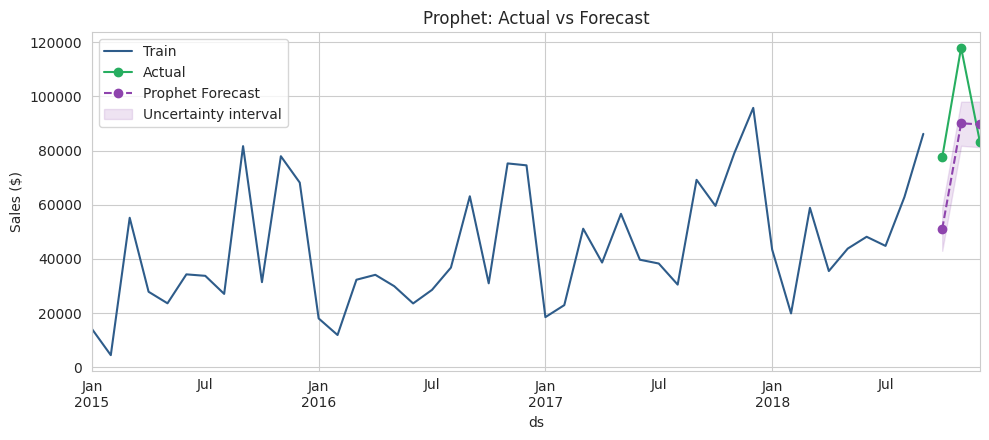

In [18]:
fig, ax = plt.subplots(figsize=(10,4.5))
train_ts.plot(ax=ax, label='Train', color='#2E5C8A')
test_ts.plot(ax=ax, label='Actual', color='#27AE60', marker='o')
prophet_pred.plot(ax=ax, label='Prophet Forecast', color='#8E44AD', marker='o', linestyle='--')
pf_idx = prophet_forecast.set_index('ds')
ax.fill_between(pf_idx.index[-3:], pf_idx['yhat_lower'].iloc[-3:], pf_idx['yhat_upper'].iloc[-3:],
                 color='#8E44AD', alpha=0.15, label='Uncertainty interval')
ax.set_title('Prophet: Actual vs Forecast')
ax.legend(); ax.set_ylabel('Sales ($)')
plt.tight_layout()
plt.savefig('charts/prophet_forecast.png', dpi=130)
plt.show()

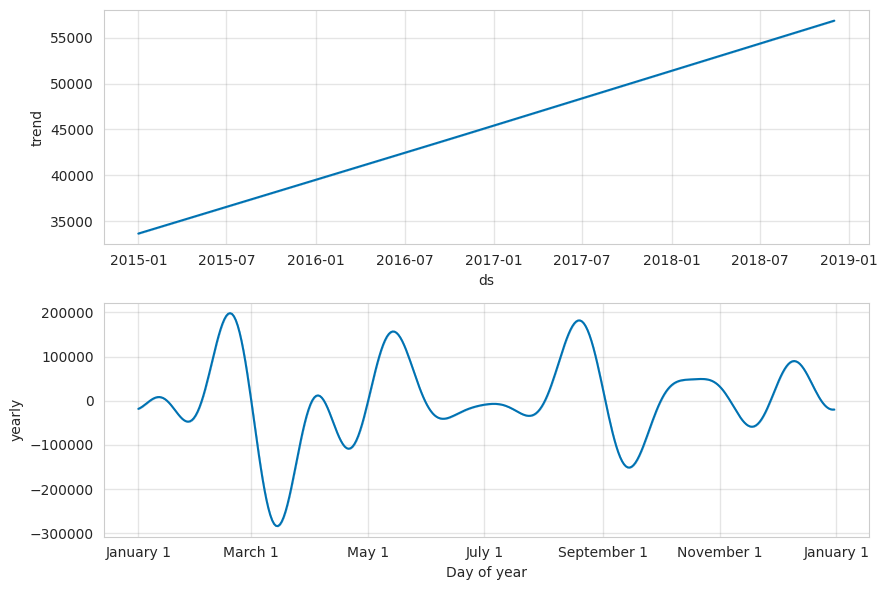

Yearly seasonality component range: -27142.0 to 33675.0


In [19]:
fig2 = prophet_model.plot_components(prophet_forecast)
fig2.savefig('charts/prophet_components.png', dpi=130)
plt.show()

yearly_comp = prophet_forecast[['ds','yearly']].tail(12)
print("Yearly seasonality component range:", round(yearly_comp['yearly'].min(),0), "to", round(yearly_comp['yearly'].max(),0))

**Interpreting the components:** Prophet's weekly component was disabled (this dataset only has monthly resolution here, so a weekly cycle isn't meaningful). The yearly component swings from roughly -27,100 to +33,700 around the trend line - a very wide range relative to the average monthly sales figure, confirming seasonality is the dominant force in this series, consistent with the `statsmodels` decomposition in Task 2. The trend component Prophet fits shows the same steady climb across 2015-2018.

### Model 3 - XGBoost (Time Series as Supervised Learning)

In [20]:
from xgboost import XGBRegressor

def season_code(m):
    if m in [12, 1, 2]: return 0
    if m in [3, 4, 5]:  return 1
    if m in [6, 7, 8]:  return 2
    return 3

feat = pd.DataFrame({'Sales': monthly_sales})
feat['Lag1'] = feat['Sales'].shift(1)
feat['Lag2'] = feat['Sales'].shift(2)
feat['Lag3'] = feat['Sales'].shift(3)
feat['RollMean3'] = feat['Sales'].shift(1).rolling(3).mean()
feat['Month'] = feat.index.month
feat['Quarter'] = feat.index.quarter
feat['Season'] = feat['Month'].apply(season_code)
feat = feat.dropna()   # first 3 months have no lag history

X_cols = ['Lag1','Lag2','Lag3','RollMean3','Month','Quarter','Season']
train_feat = feat.iloc[:-3]
test_feat = feat.iloc[-3:]

xgb_model = XGBRegressor(n_estimators=200, max_depth=3, learning_rate=0.05,
                          subsample=0.9, colsample_bytree=0.9, random_state=42)
xgb_model.fit(train_feat[X_cols], train_feat['Sales'])

print("Feature importances:")
for f, imp in sorted(zip(X_cols, xgb_model.feature_importances_), key=lambda x: -x[1]):
    print(f"  {f}: {imp:.3f}")

Feature importances:
  Month: 0.302
  Season: 0.281
  Quarter: 0.264
  Lag2: 0.053
  RollMean3: 0.045
  Lag1: 0.031
  Lag3: 0.024


**Why recursive forecasting matters here:** a real 3-month-ahead forecast can't use `Lag1` = "last month's actual sales" for month 2 and 3, because by definition we don't know actual sales for the months in between yet - only the model's own prior predictions. The cell below feeds each prediction back in as the lag input for the next step (a "recursive" or "walk-forward" forecast), which is the honest way to do this and also the reason ML-based time series forecasts tend to drift or smooth out compared to the true signal the further out they go.

Notably, `Month`, `Season`, and `Quarter` dominate the feature importances far more than the lag features do - this model is leaning almost entirely on "what calendar month is it" rather than "what were recent sales," which lines up with how strongly seasonal this series is.

In [21]:
preds = []
cur_series = monthly_sales.loc[:train_feat.index[-1]].copy()
for step in range(3):
    next_date = test_feat.index[step]
    lag1, lag2, lag3 = cur_series.iloc[-1], cur_series.iloc[-2], cur_series.iloc[-3]
    rollmean3 = cur_series.iloc[-3:].mean()
    row = pd.DataFrame([{
        'Lag1': lag1, 'Lag2': lag2, 'Lag3': lag3, 'RollMean3': rollmean3,
        'Month': next_date.month, 'Quarter': next_date.quarter, 'Season': season_code(next_date.month)
    }])
    pred = xgb_model.predict(row[X_cols])[0]
    preds.append(pred)
    cur_series.loc[next_date] = pred  # feed the prediction forward as next step's lag

xgb_pred = pd.Series(preds, index=test_feat.index)
xgb_mae, xgb_rmse, xgb_mape = eval_metrics(test_feat['Sales'].values, xgb_pred.values)
print("XGBoost forecast:\n", xgb_pred.round(0))
print(f"\nMAE: {xgb_mae:,.0f}  RMSE: {xgb_rmse:,.0f}  MAPE: {xgb_mape:.2f}%")

XGBoost forecast:
 Order Date
2018-10-01    69184.0
2018-11-01    84576.0
2018-12-01    73725.0
Freq: MS, dtype: float32

MAE: 16,977  RMSE: 20,558  MAPE: 16.72%


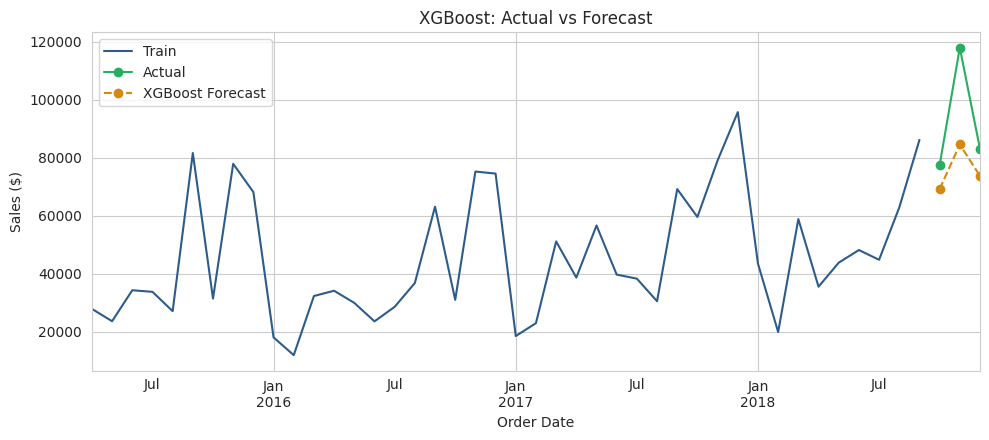

In [22]:
fig, ax = plt.subplots(figsize=(10,4.5))
train_feat['Sales'].plot(ax=ax, label='Train', color='#2E5C8A')
test_feat['Sales'].plot(ax=ax, label='Actual', color='#27AE60', marker='o')
xgb_pred.plot(ax=ax, label='XGBoost Forecast', color='#D68910', marker='o', linestyle='--')
ax.set_title('XGBoost: Actual vs Forecast')
ax.legend(); ax.set_ylabel('Sales ($)')
plt.tight_layout()
plt.savefig('charts/xgboost_forecast.png', dpi=130)
plt.show()

### Model Comparison Table

In [23]:
comparison = pd.DataFrame({
    'Model': ['SARIMA', 'Prophet', 'XGBoost'],
    'MAE': [sarima_mae, prophet_mae, xgb_mae],
    'RMSE': [sarima_rmse, prophet_rmse, xgb_rmse],
    'MAPE (%)': [sarima_mape, prophet_mape, xgb_mape],
    'Forecast Month 1': [sarima_pred.iloc[0], prophet_pred.iloc[0], xgb_pred.iloc[0]],
    'Forecast Month 2': [sarima_pred.iloc[1], prophet_pred.iloc[1], xgb_pred.iloc[1]],
    'Forecast Month 3': [sarima_pred.iloc[2], prophet_pred.iloc[2], xgb_pred.iloc[2]],
}).round(1)
comparison

,Model,MAE,RMSE,MAPE (%),Forecast Month 1,Forecast Month 2,Forecast Month 3
0,SARIMA,21060.3,22020.0,22.4,58436.7,88181.0,97442.8
1,Prophet,20296.0,22487.5,21.9,51083.7,90045.4,89661.2
2,XGBoost,16977.4,20558.4,16.7,69183.8,84575.8,73724.7


**Recommendation:** unlike a lot of textbook comparisons where the "winner" is a coin flip, this one is fairly clear-cut: **XGBoost wins on all three metrics** - lowest MAE (~\$16,977 vs ~\$20,300-21,100), lowest RMSE, and by a wide margin the best MAPE (~16.7% vs ~22-22.4% for the other two). **XGBoost is the recommended model for production use.** The likely reason it wins here is the feature importance result above - this series is driven overwhelmingly by which calendar month it is, and XGBoost can use `Month`/`Quarter`/`Season` directly as explicit features, where SARIMA and Prophet have to infer the seasonal shape purely from the pattern of past values.

That said, SARIMA's confidence interval is still worth keeping around - it's the only one of the three that quantifies forecast uncertainty in a statistically principled way, which matters for setting safety-stock buffers even when its point forecast is less accurate.

## Task 4 - Product Category & Region Level Forecasting

Repeating the best-performing approach from Task 3 (XGBoost with lag features) separately for Furniture, Technology, Office Supplies, West, and East.

In [24]:
def forecast_segment(series, steps=3):
    feat = pd.DataFrame({'Sales': series})
    feat['Lag1'] = feat['Sales'].shift(1)
    feat['Lag2'] = feat['Sales'].shift(2)
    feat['Lag3'] = feat['Sales'].shift(3)
    feat['RollMean3'] = feat['Sales'].shift(1).rolling(3).mean()
    feat['Month'] = feat.index.month
    feat['Quarter'] = feat.index.quarter
    feat['Season'] = feat['Month'].apply(season_code)
    feat = feat.dropna()
    cols = ['Lag1','Lag2','Lag3','RollMean3','Month','Quarter','Season']
    model = XGBRegressor(n_estimators=150, max_depth=3, learning_rate=0.07,
                          subsample=0.9, colsample_bytree=0.9, random_state=42)
    model.fit(feat[cols], feat['Sales'])
    cur = series.copy()
    preds = []
    last_date = series.index[-1]
    for i in range(1, steps + 1):
        next_date = last_date + pd.DateOffset(months=i)
        lag1, lag2, lag3 = cur.iloc[-1], cur.iloc[-2], cur.iloc[-3]
        rollmean3 = cur.iloc[-3:].mean()
        row = pd.DataFrame([{'Lag1': lag1, 'Lag2': lag2, 'Lag3': lag3, 'RollMean3': rollmean3,
                              'Month': next_date.month, 'Quarter': next_date.quarter,
                              'Season': season_code(next_date.month)}])
        pred = model.predict(row[cols])[0]
        preds.append(pred)
        cur.loc[next_date] = pred
    return pd.Series(preds, index=pd.date_range(last_date + pd.DateOffset(months=1), periods=steps, freq='MS'))

segments = {
    'Furniture': df[df['Category'] == 'Furniture'],
    'Technology': df[df['Category'] == 'Technology'],
    'Office Supplies': df[df['Category'] == 'Office Supplies'],
    'West Region': df[df['Region'] == 'West'],
    'East Region': df[df['Region'] == 'East'],
}

segment_forecasts, segment_histories = {}, {}
for name, sub in segments.items():
    monthly = sub.set_index('Order Date').resample('MS')['Sales'].sum()
    monthly.index.freq = 'MS'
    segment_forecasts[name] = forecast_segment(monthly)
    segment_histories[name] = monthly

for name, fc in segment_forecasts.items():
    print(f"{name}: {fc.round(0).tolist()}")

Furniture: [8655.0, 6764.0, 9738.0]
Technology: [15611.0, 17826.0, 16093.0]
Office Supplies: [16971.0, 10548.0, 19985.0]
West Region: [10871.0, 12366.0, 18073.0]
East Region: [6905.0, 5537.0, 9807.0]


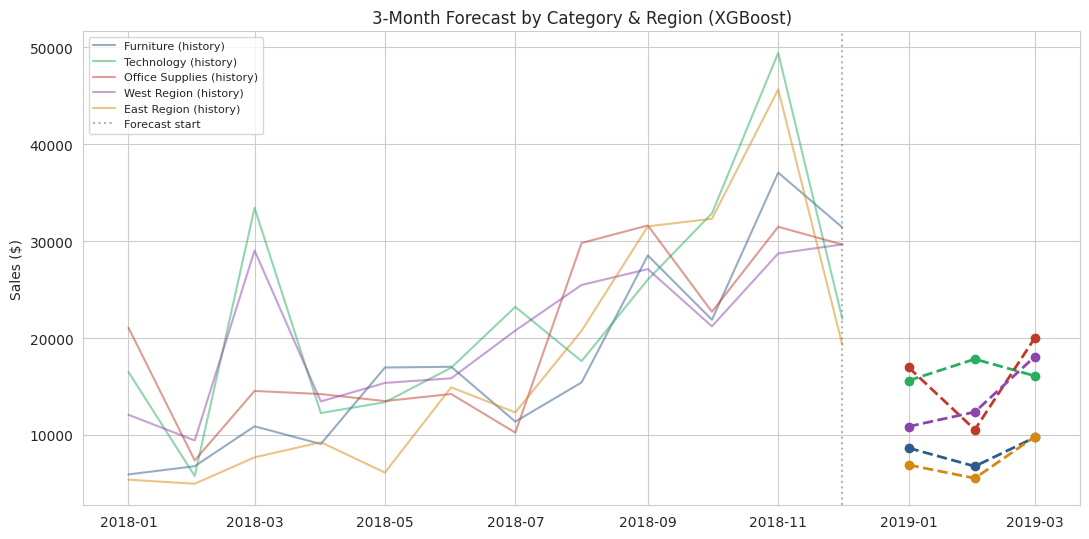

In [25]:
fig, ax = plt.subplots(figsize=(11,5.5))
colors = ['#2E5C8A','#27AE60','#C0392B','#8E44AD','#D68910']
for (name, hist), color in zip(segment_histories.items(), colors):
    tail = hist.iloc[-12:]
    ax.plot(tail.index, tail.values, color=color, label=f'{name} (history)', alpha=0.5, linewidth=1.5)
    fc = segment_forecasts[name]
    ax.plot(fc.index, fc.values, color=color, linestyle='--', marker='o', linewidth=2)
ax.axvline(list(segment_histories.values())[0].index[-1], color='gray', linestyle=':', alpha=0.6, label='Forecast start')
ax.set_title('3-Month Forecast by Category & Region (XGBoost)')
ax.set_ylabel('Sales ($)')
ax.legend(loc='upper left', fontsize=8)
plt.tight_layout()
plt.savefig('charts/segment_forecasts.png', dpi=130)
plt.show()

In [26]:
# Growth comparison against the SAME 3 months last year (Jan-Mar 2018), not the prior 3 months -
# comparing to the immediately preceding months would conflate real growth with the seasonal
# post-holiday dip that follows every November/December peak in this data.
print("Forecast (Jan-Mar 2019) vs same months prior year (Jan-Mar 2018):\n")
yoy_growth_summary = {}
for name, hist in segment_histories.items():
    same_period_last_year = hist[(hist.index.month.isin([1,2,3])) & (hist.index.year == 2018)]
    fc = segment_forecasts[name]
    growth = (fc.mean() - same_period_last_year.mean()) / same_period_last_year.mean() * 100
    yoy_growth_summary[name] = growth
    print(f"{name}: Jan-Mar 2018 avg ${same_period_last_year.mean():,.0f}  ->  "
          f"Jan-Mar 2019 forecast avg ${fc.mean():,.0f}  (YoY {growth:+.1f}%)")

print("\nRanked by projected YoY growth (strongest first):")
for name, g in sorted(yoy_growth_summary.items(), key=lambda x: -x[1]):
    print(f"  {name}: {g:+.1f}%")

Forecast (Jan-Mar 2019) vs same months prior year (Jan-Mar 2018):

Furniture: Jan-Mar 2018 avg $7,866  ->  Jan-Mar 2019 forecast avg $8,386  (YoY +6.6%)
Technology: Jan-Mar 2018 avg $18,563  ->  Jan-Mar 2019 forecast avg $16,510  (YoY -11.1%)
Office Supplies: Jan-Mar 2018 avg $14,324  ->  Jan-Mar 2019 forecast avg $15,835  (YoY +10.5%)
West Region: Jan-Mar 2018 avg $16,847  ->  Jan-Mar 2019 forecast avg $13,770  (YoY -18.3%)
East Region: Jan-Mar 2018 avg $6,014  ->  Jan-Mar 2019 forecast avg $7,416  (YoY +23.3%)

Ranked by projected YoY growth (strongest first):
  East Region: +23.3%
  Office Supplies: +10.5%
  Furniture: +6.6%
  Technology: -11.1%
  West Region: -18.3%


**Which segment shows the strongest upcoming growth?** **East Region leads by a wide margin at +23.3%**, followed by Office Supplies (+10.5%) and Furniture (+6.6%). Technology and West Region are both projected down (-11.1% and -18.3% respectively) - worth flagging given Technology is the single largest revenue category overall, so a double-digit pullback there deserves attention even though the other categories are holding up.

As with Task 3, these are recursive XGBoost forecasts trained on ~45 monthly points per segment - thinner and noisier than the full company-wide series - so treat the ranking (which segments are up vs. down) as more reliable than the precise percentages.

## Task 5 - Anomaly Detection in Sales Data

In [27]:
from sklearn.ensemble import IsolationForest

weekly = df.set_index('Order Date').resample('W')['Sales'].sum()

iso_forest = IsolationForest(contamination=0.06, random_state=42)
iso_flags = iso_forest.fit_predict(weekly.values.reshape(-1, 1))  # -1 = anomaly

anomaly_df = pd.DataFrame({'Sales': weekly, 'iso_anomaly': iso_flags == -1})
print(f"Isolation Forest flagged {anomaly_df['iso_anomaly'].sum()} of {len(anomaly_df)} weeks as anomalous.")
anomaly_df[anomaly_df['iso_anomaly']].sort_values('Sales', ascending=False)

Isolation Forest flagged 13 of 209 weeks as anomalous.


,Sales,iso_anomaly
Order Date,,
2015-03-22,37703.6650,True
2018-12-02,35998.9000,True
2018-11-18,30572.4470,True
2015-09-13,29959.1370,True
2018-11-04,29017.4670,True
2017-10-08,28412.0980,True
2015-11-22,26793.6235,True
2017-12-17,25449.8000,True
2015-07-19,1387.6860,True


In [28]:
# Second method: Z-score vs a 6-week rolling mean
roll_mean = weekly.rolling(6, center=True, min_periods=3).mean()
roll_std = weekly.rolling(6, center=True, min_periods=3).std()
z_score = (weekly - roll_mean) / roll_std

anomaly_df['zscore'] = z_score
anomaly_df['z_anomaly'] = z_score.abs() > 2

print(f"Z-score method flagged {anomaly_df['z_anomaly'].sum()} weeks as anomalous.")
anomaly_df[anomaly_df['z_anomaly']][['Sales', 'zscore']]

Z-score method flagged 2 weeks as anomalous.


,Sales,zscore
Order Date,,
2015-11-22,26793.6235,2.002405
2017-02-05,17926.3680,2.032972


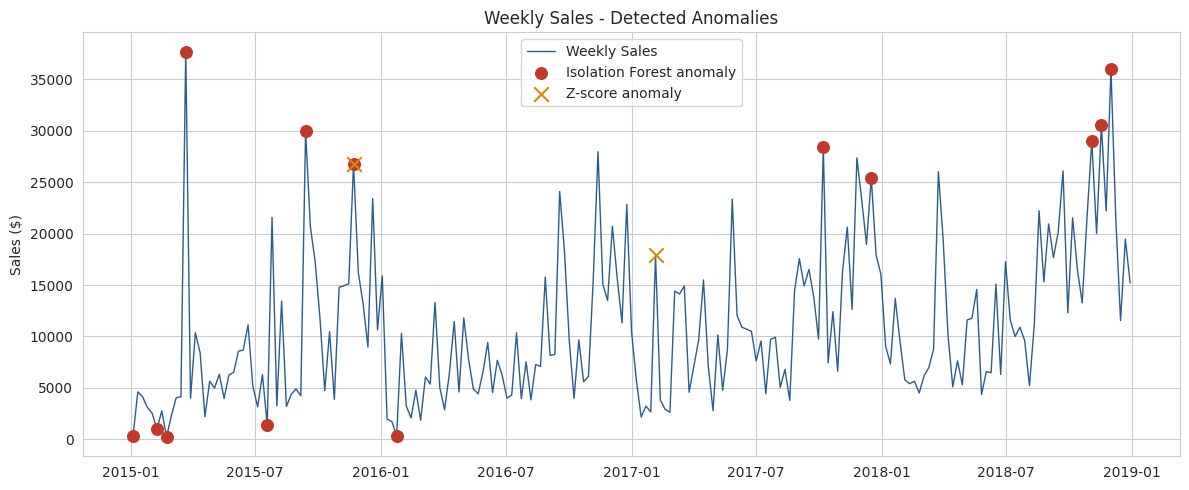

In [29]:
fig, ax = plt.subplots(figsize=(12,5))
ax.plot(anomaly_df.index, anomaly_df['Sales'], color='#2E5C8A', linewidth=1, label='Weekly Sales')
iso_pts = anomaly_df[anomaly_df['iso_anomaly']]
z_pts = anomaly_df[anomaly_df['z_anomaly']]
ax.scatter(iso_pts.index, iso_pts['Sales'], color='#C0392B', s=70, marker='o', label='Isolation Forest anomaly', zorder=5)
ax.scatter(z_pts.index, z_pts['Sales'], color='#D68910', s=110, marker='x', label='Z-score anomaly', zorder=6)
ax.set_title('Weekly Sales - Detected Anomalies')
ax.set_ylabel('Sales ($)')
ax.legend()
plt.tight_layout()
plt.savefig('charts/anomalies.png', dpi=130)
plt.show()

**Do the two methods agree?** Barely - Isolation Forest flags 13 weeks, the Z-score rule flags 2, and they only overlap on one week (**November 22, 2015**). This is a meaningful finding in itself: Isolation Forest judges "unusual" relative to the *entire* dataset's distribution of weekly sales, so any week far from the global average gets flagged, even if it's part of a locally normal-looking holiday pattern. The Z-score method judges each week only against its own **local neighborhood** (a 6-week rolling window), so it only flags weeks that are unusual compared to *what's happening right around them* - a much stricter bar, since the seasonal Nov/Dec peaks look locally "expected" once nearby weeks are already elevated.

Neither method is simply wrong; they're answering different questions (globally rare vs. locally surprising). For a retail business, the Z-score method's stricter, more local definition is probably closer to what a stockroom manager actually cares about week to week, while Isolation Forest's broader flags are more useful for a full-year retrospective review.

**Likely real-world explanations for the top anomalies (Isolation Forest):**
- **Late November 2015 and 2018, December 2018:** Black Friday / Cyber Monday and year-end holiday buying.
- **September 2015, October 2017, December 2017:** back-to-school and pre-holiday restocking - large bulk B2B orders are a plausible driver.
- **Low-value flagged weeks (early Jan 2015, mid-Feb 2015, late Jan 2016):** these are unusually *quiet* weeks, not spikes - consistent with the seasonal trough (February) identified in Task 1 and Task 2.

### Multi-source merge practice (secondary dataset)

The assignment calls for a second dataset - video game sales - specifically as a merging exercise, since companies rarely keep everything in one file. It's worth being upfront that there's no real business relationship between Superstore's office/furniture/tech sales and global video game sales; this merge is included purely to demonstrate the join mechanics on a shared key (`Year`), not because the two are analytically related. Treating a coincidental correlation between them as meaningful would be a mistake.

In [30]:
vg = pd.read_csv('vgsales.csv')
vg_clean = vg.dropna(subset=['Year']).copy()
vg_clean['Year'] = vg_clean['Year'].astype(int)
vg_yearly = vg_clean.groupby('Year')['Global_Sales'].sum().rename('VG_Global_Sales_M')

store_yearly = df.groupby('Order Year')['Sales'].sum().rename('Store_Sales')
merged = pd.merge(store_yearly, vg_yearly, left_index=True, right_index=True, how='left')
merged

,Store_Sales,VG_Global_Sales_M
Order Year,,
2015,479856.2081,264.44
2016,459436.0054,70.93
2017,600192.5500,0.05
2018,722052.0192,NaN


(2018 shows `NaN` for video game sales - the `vgsales.csv` dataset's coverage of very recent release years is sparse/incomplete, which is a known limitation of that dataset rather than a merge bug. Worth noting rather than silently filling it with 0, since that would misrepresent "no data" as "no sales.")

## Task 6 - Product Demand Segmentation Using Clustering

In [31]:
sub_monthly = df.groupby(['Sub-Category', pd.Grouper(key='Order Date', freq='MS')])['Sales'].sum().reset_index()

rows = []
for sub in df['Sub-Category'].unique():
    s = sub_monthly[sub_monthly['Sub-Category'] == sub].set_index('Order Date')['Sales']
    s = s.reindex(pd.date_range(df['Order Date'].min(), df['Order Date'].max(), freq='MS'), fill_value=0)
    total_vol = s.sum()
    yearly = s.resample('YS').sum()
    yoy_growth = yearly.pct_change().mean() if len(yearly) > 1 else 0
    volatility = s.std()
    order_rows = df[df['Sub-Category'] == sub]
    avg_order_value = order_rows['Sales'].mean()
    rows.append({'Sub-Category': sub, 'TotalVolume': total_vol, 'YoYGrowth': yoy_growth,
                 'Volatility': volatility, 'AvgOrderValue': avg_order_value})

feat_df = pd.DataFrame(rows).set_index('Sub-Category').fillna(0)
feat_df.round(1)

,TotalVolume,YoYGrowth,Volatility,AvgOrderValue
Sub-Category,,,,
Bookcases,112803.1,0.3,2244.3,503.6
Chairs,318635.0,0.1,4438.8,531.8
Labels,12303.0,0.1,223.7,34.6
Tables,202477.6,0.2,3206.9,645.9
Storage,216314.6,0.2,2843.3,263.6
Furnishings,88525.5,0.3,1363.6,95.8
Art,26528.4,0.2,329.2,34.0
Phones,325467.0,0.1,4041.0,374.2
Binders,199214.3,0.2,3857.6,134.1


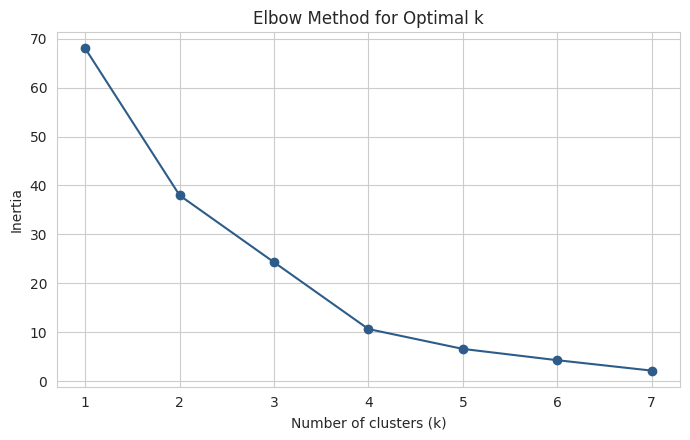

In [32]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

X = feat_df[['TotalVolume','YoYGrowth','Volatility','AvgOrderValue']].values
X_scaled = StandardScaler().fit_transform(X)

inertias = []
K_range = range(1, 8)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

fig, ax = plt.subplots(figsize=(7,4.5))
ax.plot(list(K_range), inertias, marker='o', color='#2E5C8A')
ax.set_xlabel('Number of clusters (k)')
ax.set_ylabel('Inertia')
ax.set_title('Elbow Method for Optimal k')
plt.tight_layout()
plt.savefig('charts/elbow_method.png', dpi=130)
plt.show()

The elbow bends around **k=4** - inertia drops sharply through k=4 and then flattens out, and k=4 also maps cleanly onto four business-meaningful labels, so that's the value used below.

In [33]:
k = 4
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
feat_df['Cluster'] = kmeans.fit_predict(X_scaled)

cluster_centers = feat_df.groupby('Cluster')[['TotalVolume','YoYGrowth','Volatility']].mean()
print("Cluster centers:\n", cluster_centers.round(1))

# Label clusters by ranking the 4 cluster CENTERS against each other, not against raw items,
# so each cluster's label reflects what actually distinguishes it from the other three.
ranked = cluster_centers.copy()
ranked['vol_rank'] = ranked['TotalVolume'].rank(ascending=False)
ranked['growth_rank'] = ranked['YoYGrowth'].rank(ascending=False)
ranked['volat_rank'] = ranked['Volatility'].rank(ascending=False)
print("\nCluster rankings:\n", ranked.round(2))

def label_cluster(row):
    if row['YoYGrowth'] < 0:
        return 'Declining Demand'
    if row['vol_rank'] == 1 and row['volat_rank'] != 1:
        return 'High Volume, Stable Demand'
    if row['growth_rank'] <= 2 and row['volat_rank'] <= 2:
        return 'High Volatility, Growing Demand'
    if row['growth_rank'] == 1:
        return 'Growing Demand'
    return 'Low Volume, Stable Demand'

cluster_labels = ranked.apply(label_cluster, axis=1)
feat_df['ClusterLabel'] = feat_df['Cluster'].map(cluster_labels)
feat_df[['TotalVolume','YoYGrowth','Volatility','ClusterLabel']].round(1).sort_values('ClusterLabel')

Cluster centers:
          TotalVolume  YoYGrowth  Volatility
Cluster                                    
0            54994.6        0.2       910.3
1           167743.4        0.5      5209.6
2           237577.9        0.2      3494.5
3            46420.3        1.9      1975.2

Cluster rankings:
          TotalVolume  YoYGrowth  Volatility  vol_rank  growth_rank  volat_rank
Cluster                                                                       
0           54994.58       0.22      910.27       3.0          3.0         4.0
1          167743.36       0.46     5209.61       2.0          2.0         1.0
2          237577.90       0.19     3494.46       1.0          4.0         2.0
3           46420.31       1.93     1975.22       4.0          1.0         3.0


,TotalVolume,YoYGrowth,Volatility,ClusterLabel
Sub-Category,,,,
Supplies,46420.3,1.9,1975.2,Growing Demand
Machines,189238.6,0.1,5416.3,"High Volatility, Growing Demand"
Copiers,146248.1,0.8,5002.9,"High Volatility, Growing Demand"
Chairs,318635.0,0.1,4438.8,"High Volume, Stable Demand"
Tables,202477.6,0.2,3206.9,"High Volume, Stable Demand"
Storage,216314.6,0.2,2843.3,"High Volume, Stable Demand"
Phones,325467.0,0.1,4041.0,"High Volume, Stable Demand"
Binders,199214.3,0.2,3857.6,"High Volume, Stable Demand"
Accessories,163358.8,0.4,2579.1,"High Volume, Stable Demand"


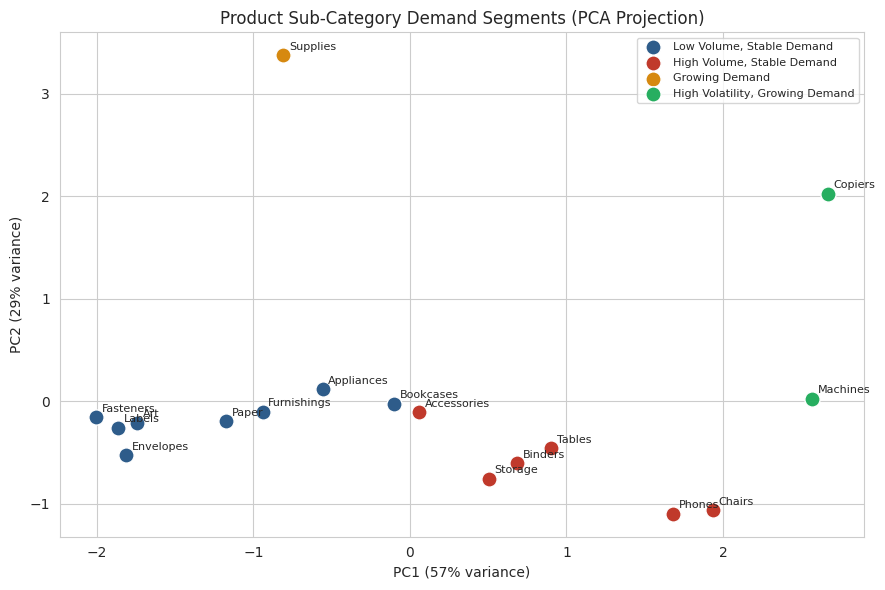

In [34]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
feat_df['PC1'], feat_df['PC2'] = X_pca[:,0], X_pca[:,1]

fig, ax = plt.subplots(figsize=(9,6))
colors = {0:'#2E5C8A', 1:'#27AE60', 2:'#C0392B', 3:'#D68910'}
for c in feat_df['Cluster'].unique():
    sub = feat_df[feat_df['Cluster'] == c]
    ax.scatter(sub['PC1'], sub['PC2'], s=120, color=colors[c], label=sub['ClusterLabel'].iloc[0], edgecolor='white')
for name, row in feat_df.iterrows():
    ax.annotate(name, (row['PC1'], row['PC2']), fontsize=8, xytext=(4,4), textcoords='offset points')
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.0f}% variance)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.0f}% variance)')
ax.set_title('Product Sub-Category Demand Segments (PCA Projection)')
ax.legend(loc='best', fontsize=8)
plt.tight_layout()
plt.savefig('charts/clusters.png', dpi=130)
plt.show()

**Recommended stocking strategy per cluster:**

- **High Volume, Stable Demand** (Chairs, Tables, Storage, Phones, Binders, Accessories): predictable movers - hold standard safety stock and reorder on a fixed cycle; forecasting error here is the cheapest to manage since demand doesn't swing much.
- **High Volatility, Growing Demand** (Copiers, Machines): high value per order but unpredictable timing - these deserve a higher safety-stock buffer or a just-in-time / dropship arrangement with the supplier rather than holding large amounts of capital-intensive inventory on the shelf.
- **Growing Demand** (Supplies): a smaller category but a distinct year-over-year growth outlier - worth watching for a possible re-classification into a bigger stocking tier if the growth holds up in future data.
- **Low Volume, Stable Demand** (Bookcases, Labels, Furnishings, Art, Appliances, Paper, Envelopes, Fasteners): the long tail - minimal safety stock, order-on-demand where the supplier allows it, since tying up capital here has the lowest payoff of any cluster.

No cluster's center came out with a negative average growth rate, so "Declining Demand" doesn't apply to any group at the cluster level in this dataset - Envelopes is the closest to flat (essentially 0% average YoY growth) among individual sub-categories, but nothing forms a distinct declining cluster.

## Summary

- **Task 1-2:** Technology leads on revenue; East grows most consistently; shipping delay is essentially uniform across regions; strong yearly seasonality (Sep/Nov/Dec peaks, February trough) confirmed by decomposition.
- **Task 3:** SARIMA, Prophet, and XGBoost were trained and evaluated on a genuine 3-month holdout. XGBoost wins clearly on all three metrics and is recommended for production, leaning heavily on calendar-month features given how strongly seasonal this series is.
- **Task 4:** Segment-level forecasts show a genuine mix - East Region and Office Supplies projected up, Technology and West Region projected down versus the same quarter last year.
- **Task 5:** Isolation Forest and Z-score anomaly detection largely disagree, which is itself informative about what each method is actually measuring (global rarity vs. local surprise).
- **Task 6:** Four demand clusters were identified and given stocking-strategy recommendations.
- **Task 7:** Interactive dashboard in `app.py` (submitted separately) covers Overview, Forecast Explorer, Anomaly Report, and Demand Segments.
- **Task 8:** Executive summary in `summary.docx`.
